Programma basato sul paper di Miura e Maini per simulare un pattern di Turing

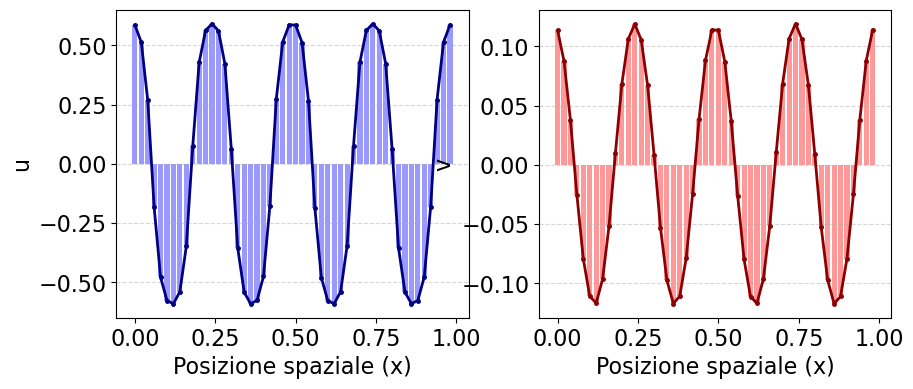

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
plt.rcParams.update({
    "font.size": 16,
})

n = 50 ##numero cellule
u = rng.uniform(-0.05, 0.05, n) ##condizioni iniziali per l'attivatore
v = rng.uniform(-0.05, 0.05, n) ##condizioni iniziali per l'inibitore
u_d = np.zeros(len(u))
v_d = np.zeros(len(v))
dx = 0.02
x = np.arange(0, dx*n, dx)
dt = 0.01
Du = 0.0002
Dv = 0.01
t = 1000
it = t/dt
for k in range(int(it)):##condizioni di flusso nullo, 1D
    u_r = dt * (0.6 * u - v - np.power(u, 3))
    v_r = dt * ( 1.5 * u - 2 * v)
    #Primo elemento
    u_d[0] = (dt / pow(dx,2))* Du *(u[1]-u[0])
    v_d[0] = (dt / pow(dx,2))* Dv *(v[1]-v[0])
    #Ultimo elemento
    u_d[-1] = (dt / pow(dx,2))* Du *(u[-2]-u[-1])
    v_d[-1] = (dt / pow(dx,2))* Dv *(v[-2]-v[-1])
    #Diffusione
    u_d[1:-1] = (dt / pow(dx,2)) * Du * (u[:-2] + u[2:] - 2 * u[1:-1])
    v_d[1:-1] = (dt / pow(dx,2)) * Dv * (v[:-2] + v[2:] - 2 * v[1:-1])
    #Relazioni finali
    u = u + u_r + u_d
    v = v + v_r + v_d

larghezza_barra = dx * 0.8
plt.figure(figsize=(10, 4)) 

plt.subplot(1, 2, 1)
plt.bar(x, u, width=larghezza_barra, color='blue', alpha=0.4, align='center')
plt.plot(x, u, color='navy', linewidth=2, marker='.', markersize=5)
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('u')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.subplot(1, 2, 2)
plt.bar(x, v, width=larghezza_barra, color='red', alpha=0.4, align='center')
plt.plot(x, v, color='darkred', linewidth=2, marker='.', markersize=5)
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('v')
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [ ]:
2) Pattern di Turing in un sistema discreto

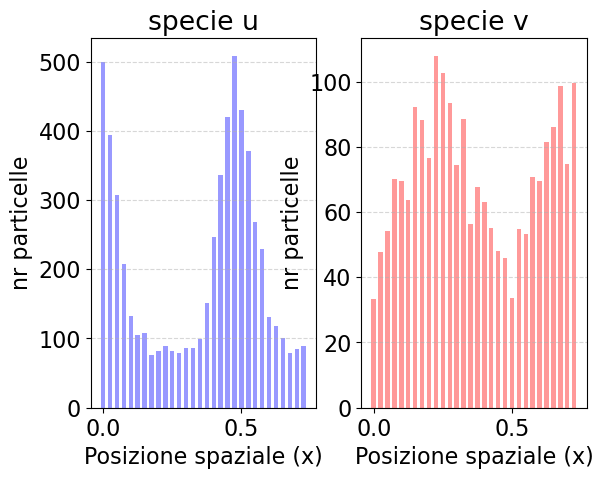

In [7]:
num = 30
#scala del sistema simulato
scala = 1.0
h = scala * 200
k = scala * 75


n_u = np.zeros(num) + h
n_u_d = np.zeros(num)
n_u_mult = np.zeros((num, 2))


n_v = np.zeros(num) + k
n_v_d = np.zeros(num)
n_v_mult = np.zeros((num, 2))


Du = 1e-5
Dv = 1e-3
dx = 0.025
dt = 0.01

## Probabilità associata alla binomiale
alpha_u = 2 * (dt / (dx**2)) * Du  
alpha_v = 2 * (dt / (dx**2)) * Dv

if alpha_u > 1.0 or alpha_v > 1.0:
    raise ValueError("Attenzione: dt troppo grande o dx troppo piccolo. Probabilità > 1")

t_tot = 10000
passi = int(t_tot / dt)
x = np.arange(0, dx * num, dx)

## Parametri cinetici
c = 1.0
k1 = 1e-6 / (scala * scala)
k2 = 1.0 * scala
k3 = 2e-2
k4 = 3.0 * scala

for i in range(passi):
    
    ## --- SPECIE U ---
    # Controllo per impedire valori negativi nella binomiale
    n_u_int = np.maximum(np.round(n_u).astype(int), 0)
    
    n_u_p = rng.binomial(n_u_int, alpha_u)
    n_u_mult = rng.multinomial(n_u_p, pvals=[0.5, 0.5])
    
    n_u_d = - n_u_p
    n_u_dx = n_u_mult[:, 0]
    n_u_sx = n_u_mult[:, 1]
    
    ## particelle entranti dalle celle a destra
    n_u_d[:-1] += n_u_sx[1:]
    ## rimbalzo sul lato di sinistra
    n_u_d[0] += n_u_sx[0]
    
    ## particelle entranti dalle celle a sinistra
    n_u_d[1:] += n_u_dx[:-1]
    ## rimbalzo sul lato di destra
    n_u_d[-1] += n_u_dx[-1]


    ## --- SPECIE V ---
    # Controllo per impedire valori negativi nella binomiale
    n_v_int = np.maximum(np.round(n_v).astype(int), 0)
    
    n_v_p = rng.binomial(n_v_int, alpha_v)
    n_v_mult = rng.multinomial(n_v_p, pvals=[0.5, 0.5])
    
    n_v_d = - n_v_p
    n_v_dx = n_v_mult[:, 0]
    n_v_sx = n_v_mult[:, 1]
    
    ## particelle entranti dalle celle a destra 
    n_v_d[:-1] += n_v_sx[1:]
    ## rimbalzo sul lato di sinistra
    n_v_d[0] += n_v_sx[0]
    
    ## particelle entranti dalle celle a sinistra 
    n_v_d[1:] += n_v_dx[:-1]
    ## rimbalzo sul lato di destra
    n_v_d[-1] += n_v_dx[-1]
    
    
    ## --- REAZIONE ---
    
    n_u_r = dt * (c * k1 * n_v * (n_u**2) + k2 - k3 * n_u)
    n_v_r = dt * (-k1 * c * n_v * (n_u**2) + k4)
    
    ## aggiornamento matrici n_u e n_v
    n_u = n_u + n_u_r + n_u_d
    n_v = n_v + n_v_r + n_v_d

plt.subplot(1, 2, 1)
plt.bar(x, n_u, width=larghezza_barra, color='blue', alpha=0.4, align='center')
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('nr particelle')
plt.title('specie u')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.subplot(1, 2, 2)
plt.bar(x, n_v, width=larghezza_barra, color='red', alpha=0.4, align='center')
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('nr particelle')
plt.title('specie v')
plt.grid(axis='y', linestyle='--', alpha=0.5)


In [ ]:
3) simulazione stocastica

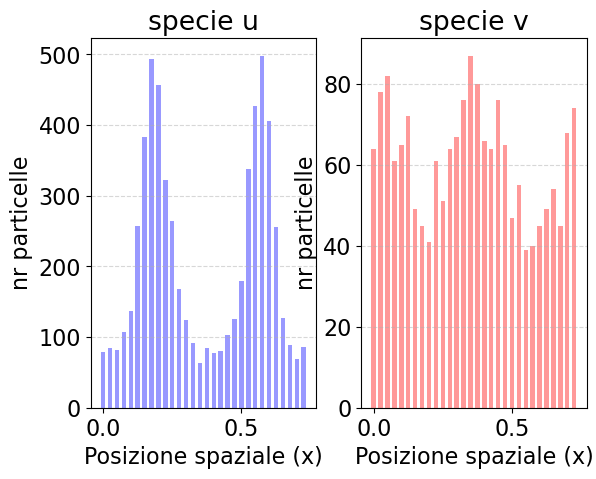

In [11]:
from numba import njit

rng = np.random.default_rng()

## Parametri del sistema 
n = 30 
dx = 0.025
Du = 1e-5
Dv = 1e-3


t_current = 0.0
t_end = 10000.0


## rate di diffusione
d_u = Du / (dx * dx)
d_v = Dv / (dx * dx)

# --- FUNZIONE COMPILATA CON NUMBA ---
@njit
def simulazione(u, v, d_u, d_v, k1, k2, k3, k4, t_end, n):
    t_current = 0.0
    
    ## Rate costanti 
    rate_2 = np.zeros(n) + k2
    rate_4 = np.zeros(n) + k4
    
    while t_current < t_end:
        # 1. Calcolo delle propensioni per movimenti a destra e a sinistra per le due specie
        rate_right_u = u[:-1] * d_u
        rate_left_u = u[1:] * d_u
        
        rate_right_v = v[:-1] * d_v
        rate_left_v = v[1:] * d_v
        
        # 2. Calcolo delle propensioni per le reazioni chimiche
        rate_1 = u * (u - 1) * v * k1
        #rate_2 = np.zeros(n) + k2
        rate_3 = u * k3
        #rate_4 = np.zeros(n) + k4
        
        # Propensione totale
        prop_tot = (np.sum(rate_right_u) + np.sum(rate_left_u)
        + np.sum(rate_right_v) + np.sum(rate_left_v) + np.sum(rate_1)
        + np.sum(rate_2) + np.sum(rate_3) + np.sum(rate_4))
        
        
        # Se la propensione è 0, il sistema è congelato
        if prop_tot == 0:
            break
            
        r1 = np.random.rand()
        r2 = np.random.rand()
        
        # 2. Aggiornamento del tempo
        tau = (1 / prop_tot) * np.log(1 / r1)
        t_current += tau
        
        # 3. Selezione dell'evento
        # Concateno tutti i rate in ordine: U dx, U sx, V dx, V sx, r1
        # Numba richiede una tupla
        rates = np.concatenate((
            rate_right_u, rate_left_u, rate_right_v,
            rate_left_v, rate_1, rate_2, rate_3, rate_4
        ))
        
        # probabilità cumulative
        cumulative_probs = np.cumsum(rates) / prop_tot
        
        # Trovo l'indice dell'evento che si è verificato
        event_index = np.searchsorted(cumulative_probs, r2)
        
        # 4. Esecuzione dell'evento
        L = n - 1 # Lunghezza di ogni blocco di rate per la diffusione
        
        if event_index < L:
            # L'evento è nel primo blocco: U verso destra
            i = event_index
            u[i] -= 1
            u[i + 1] += 1
        elif event_index < 2 * L:
            # L'evento è nel secondo blocco: U verso sinistra
            i = event_index - L + 1 
            u[i] -= 1
            u[i - 1] += 1
        elif event_index < 3 * L:
            # L'evento è nel terzo blocco: V verso destra
            i = event_index - 2 * L
            v[i] -= 1
            v[i + 1] += 1
        elif event_index < 4 * L:
            # L'evento è nel quarto blocco: V verso sinistra
            i = event_index - 3 * L + 1
            v[i] -= 1
            v[i - 1] += 1
        elif event_index < 4 * L + n:
            # L'evento è nel quinto blocco: reazione U-V
            i = event_index - 4 * L
            u[i] += 1
            v[i] -= 1
        elif event_index < 4 * L + 2 * n:
            # L'evento è nel sesto blocco : produzione U
            i = event_index - (4 * L + n)
            u[i] += 1
        elif event_index < 4 * L + 3 * n:
            # L'evento è nel settimo blocco : degradazione U
            i = event_index - (4 * L + 2 * n)
            u[i] -= 1
        else:
            # L'evento è nell'ottavo blocco : produzione V
            i = event_index - (4 * L + 3 * n)
            v[i] += 1
            
    return u, v

V = 1.0
x = np.arange(n)*dx

start_u = int(np.round(200 * V))
start_v = int(np.round(75 * V))
    
k1 = 1e-6 / (V * V)
k2 = 1.0 * V
k3 = 2e-2 
k4 = 3.0 * V
    
iniz_u = np.full(n, start_u, dtype=np.int64)
iniz_v = np.full(n, start_v, dtype=np.int64)
    
    # Esegui la simulazione
u_final, v_final = simulazione(
iniz_u.copy(), iniz_v.copy(), d_u, d_v, k1, k2, k3, k4, t_end, n
)

plt.subplot(1, 2, 1)
plt.bar(x, u_final, width=larghezza_barra, color='blue', alpha=0.4, align='center')
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('nr particelle')
plt.title('specie u')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.subplot(1, 2, 2)
plt.bar(x, v_final, width=larghezza_barra, color='red', alpha=0.4, align='center')
plt.xlabel('Posizione spaziale (x)')
plt.ylabel('nr particelle')
plt.title('specie v')
plt.grid(axis='y', linestyle='--', alpha=0.5)